# Spam Detection with LSTM Networks and Transfer Learning

This lab is based on an assignment developed by Prof. Lisa Zhang.

In this assignment, we will build a recurrent neural network to classify a SMS text message
as "spam" or "not spam". In the process, you will
    
1. Clean and process text data for machine learning.
2. Understand and implement a character-level recurrent neural network.
3. Use torchtext to build recurrent neural network models.
4. Understand batching for a recurrent neural network, and use torchtext to implement RNN batching.
5. Understand how transfer learning can be applied to NLP projects.



## Overview

This notebook explores deep learning approaches for SMS spam detection using recurrent neural networks and transfer learning. It presents two complementary text classification pipelines.

The first approach builds a Long Short-Term Memory (LSTM) network from scratch using character-level representations to classify SMS messages as spam or legitimate.

The second approach applies transfer learning using a pretrained language model (ULMFiT), demonstrating how pretrained representations can improve classification accuracy while reducing training requirements.

Throughout the notebook, the complete NLP workflow is covered, including data preprocessing, vocabulary construction, sequence modeling, model training, evaluation, and comparison of both approaches.

## Learning Objectives

By completing this notebook you will learn how to:

- Build character-level LSTM classifiers
- Preprocess SMS text datasets
- Encode variable-length text sequences
- Train recurrent neural networks for text classification
- Evaluate binary classification performance
- Interpret confusion matrices
- Apply transfer learning using ULMFiT
- Compare recurrent networks with pretrained language models

# PART A - Spam Detection

In this part we will construct a LSTM model for identifying spam from non spam messages.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

## Part 1. Data Cleaning

We will be using the "SMS Spam Collection Data Set" available at http://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection

There is a link to download the "Data Folder" at the very top of the webpage. Download the zip file, unzip it, and upload the file `SMSSpamCollection` to Colab.    

### Part (a)

Open up the file in Python, and print out one example of a spam SMS, and one example of a non-spam SMS.



$\color{blue}{\text{ }}$  


- <font color=blue>the label value for a spam message is spam <font color=black>

- <font color=blue>the label value for non-spam values is ham<font color=black>

In [ ]:

for line in open('SMSSpamCollection'):
  if 'ham' in line:
    print(line)
    break



for line in open('SMSSpamCollection'):
  if 'spam' in line:
    print(line)
    break

ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's



### Part (b)

$\color{blue}{\text{ }}$  


- <font color=blue>There are 747 spam messages. <font color=black>

- <font color=blue>There are 4827 spam  non-spam messages. <font color=black>

In [ ]:
i=0
h=0

for line in open('SMSSpamCollection'):
  i+=1
  if 'spam' in line:
    h+=1



print(i-h, h)

4827 747


### Part (c) [2 pt]

We will be using the package `torchtext` to load, process, and batch the data.
A tutorial to torchtext is available below. This tutorial uses the same
Sentiment140 data set that we explored during lecture.

https://medium.com/@sonicboom8/sentiment-analysis-torchtext-55fb57b1fab8

We will be building a **character level RNN**.
That is, we will treat each **character** as a token in our sequence,
rather than each **word**.




$\color{blue}{\text{}}$  


<font color=blue>Advantages: <font color=black>
- <font color=blue>The discrete space we're working with is much smaller -- there are about 97 English-language characters in common usage if we include all punctuation marks. By contrast, a vocabulary is many thousands of words. This implies that just storing the word embeddings will require a lot of memory, and including word embeddings in a model adds many, many parameters to the model so the computational cost is much higher on this account than the character-level model. <font color=black>
- <font color=blue>Modeling as a series of characters can be used to simulate the correct sequence in a variety of languages.<font color=black>



<font color=blue>Disadvantages: <font color=black>
- <font color=blue>It's harder to train. The cross entropy loss takes the sum over all elements in each sentence. For a word-level RNN, the number of elements equals the number of words in the sentence, whereas for a character-level RNN, the number of elements equals the number of characters in the sentence. Thus, in training, it takes a longer path to propagate the error from the softmax at the last time step back to the beginning.. <font color=black>
- <font color=blue>Character level RNN should make more prediction. The more predictions the RNN has to make, the more error-prone the result is. <font color=black>

- <font color=blue>Character level models give up the semantic information that words have, as well as the plug and play ecosystem of pre-trained word vectors<font color=black>

### Part (d)
We will be loading our data set using `torchtext.data.TabularDataset`. The
constructor will read directly from the `SMSSpamCollection` file.

For the data file to be read successfuly, we
need to specify the **fields** (columns) in the file.
In our case, the dataset has two fields:

- a text field containing the sms messages,
- a label field which will be converted into a binary label.

Split the dataset into `train`, `valid`, and `test`. Use a 60-20-20 split.
You may find this torchtext API page helpful:
https://torchtext.readthedocs.io/en/latest/data.html#dataset

Hint: There is a `Dataset` method that can perform the random split for you.

In [ ]:
import torchtext

text_field = torchtext.legacy.data.Field(sequential=True,      # text sequence
                                  tokenize=lambda x: x, # because are building a character-RNN
                                  include_lengths=True, # to track the length of sequences, for batching
                                  batch_first=True,
                                  use_vocab=True)       # to turn each character into an integer index
label_field = torchtext.legacy.data.Field(sequential=False,    # not a sequence
                                   use_vocab=False,     # don't need to track vocabulary
                                   is_target=True,
                                   batch_first=True,
                                   preprocessing=lambda x: int(x == 'spam')) # convert text to 0 and 1

fields = [('label', label_field), ('sms', text_field)]
dataset = torchtext.legacy.data.TabularDataset("SMSSpamCollection", # name of the file
                                        "tsv",               # fields are separated by a tab
                                        fields)

print(dataset[0].sms)
print(dataset[0].label)
train, valid, test = dataset.split(split_ratio=[0.6,0.2,0.2])

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
0


### Part (e)

You saw in part (b) that there are many more non-spam messages than spam messages.
This **imbalance** in our training data will be problematic for training.
We can fix this disparity by duplicating spam messages in the training set,
so that the training set is roughly **balanced**.

Explain why having a balanced training set is helpful for training our neural network.

Note: if you are not sure, try removing the below code and train your mode.



$\color{blue}{\text{ }}$  

- <font color=blue>Imbalanced data is one of the potential problems in the field of data mining and machine learning. Balancing training data is an important part of data preprocessing. Data imbalance refers to when the classes in a dataset are not equally distributed, which can then lead to potential risks in training a model. By balancing the data, our model would be exposed and trained on almost as many spam messages as non-spam messages<font color=black>




In [ ]:
# save the original training examples
old_train_examples = train.examples
# get all the spam messages in `train`
train_spam = []
for item in train.examples:
    if item.label == 1:
        train_spam.append(item)
# duplicate each spam message 6 more times
train.examples = old_train_examples + train_spam * 6

### Part (f)

We need to build the vocabulary on the training data by running the below code.
This finds all the possible character tokens in the training set.

Explain what the variables `text_field.vocab.stoi` and `text_field.vocab.itos` represent.




$\color{blue}{\text{}}$  

- <font color=blue> **stoi** is  mapping token strings to numerical identifiers.<font color=black>


- <font color=blue> **itos** is a list of token strings indexed by their numerical identifiers.<font color=black>


In [ ]:
text_field.build_vocab(train)
#text_field.vocab.stoi
#text_field.vocab.itos

### Part (g)

The tokens `<unk>` and `<pad>` were not in our SMS text messages.
What do these two values represent?




$\color{blue}{\text{ }}$  

- <font color=blue> **UNK** means unknown word, a word that doesn't exist the the vocabulary set. It represents unknown or unseen characters<font color=black>


- <font color=blue> **pad** means adding padding token before or after a character to allow sentences' lengths to be equal.<font color=black>



### Part (h)

Since text sequences are of variable length, `torchtext` provides a `BucketIterator` data loader,
which batches similar length sequences together. The iterator also provides functionalities to
pad sequences automatically.

Take a look at 10 batches in `train_iter`. What is the maximum length of the
input sequence in each batch? How many `<pad>` tokens are used in each of the 10
batches?

In [ ]:
train_iter = torchtext.legacy.data.BucketIterator(train,
                                           batch_size=32,
                                           sort_key=lambda x: len(x.sms), # to minimize padding
                                           sort_within_batch=True,        # sort within each batch
                                           repeat=False)                  # repeat the iterator for many epochs

In [ ]:
i=0
for batch in train_iter:
  print('The maximum length of the input sequence in batch', i+1, 'is equal to', torch.max(batch.sms[1]))
  N_pad=0
  for j in range(len(batch.sms[0])):
      N_pad=N_pad+np.count_nonzero(np.array(batch.sms[0][j])==1) #pad token has index of 1

  print("Number of <pad> tokens are used=", N_pad)
  i+=1
  if i==10:
    break

The maximum length of the input sequence in batch 1 is equal to tensor(150)
Number of <pad> tokens are used= 10
The maximum length of the input sequence in batch 2 is equal to tensor(65)
Number of <pad> tokens are used= 60
The maximum length of the input sequence in batch 3 is equal to tensor(143)
Number of <pad> tokens are used= 0
The maximum length of the input sequence in batch 4 is equal to tensor(134)
Number of <pad> tokens are used= 49
The maximum length of the input sequence in batch 5 is equal to tensor(141)
Number of <pad> tokens are used= 9
The maximum length of the input sequence in batch 6 is equal to tensor(147)
Number of <pad> tokens are used= 27
The maximum length of the input sequence in batch 7 is equal to tensor(152)
Number of <pad> tokens are used= 0
The maximum length of the input sequence in batch 8 is equal to tensor(158)
Number of <pad> tokens are used= 0
The maximum length of the input sequence in batch 9 is equal to tensor(28)
Number of <pad> tokens are used= 3

## Part 2. Model Building

Build a recurrent neural network model, using an architecture of your choosing.
Use the one-hot embedding of each character as input to your recurrent network.
Use one or more fully-connected layers to make the prediction based on your
recurrent network output.

Instead of using the RNN output value for the final token, another often used
strategy is to max-pool over the entire output array. That is, instead of calling
something like:

```
out, _ = self.rnn(x)
self.fc(out[:, -1, :])
```

where `self.rnn` is an `nn.RNN`, `nn.GRU`, or `nn.LSTM` module, and `self.fc` is a
fully-connected
layer, we use:

```
out, _ = self.rnn(x)
self.fc(torch.max(out, dim=1)[0])
```

This works reasonably in practice. An even better alternative is to concatenate the
max-pooling and average-pooling of the RNN outputs:

```
out, _ = self.rnn(x)
out = torch.cat([torch.max(out, dim=1)[0],
                 torch.mean(out, dim=1)], dim=1)
self.fc(out)
```

We encourage you to try out all these options. The way you pool the RNN outputs
is one of the "hyperparameters" that you can choose to tune later on.

In [ ]:
def one_hot_encoding(x):
  text_field.build_vocab(train)
  ident = torch.eye(len(text_field.vocab.stoi))
  for i in range(0,len(x)):
      a = ident[x[i]].unsqueeze(0)
      if i==0:
        a_new=a
      else:
        a_new=torch.cat((a_new,a),dim=0)
  return a_new

In [ ]:
class RNN_char(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, method=1):
        super(RNN_char, self).__init__()
        self.ohe = one_hot_encoding
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        if method==1:
          self.fc = nn.Linear(hidden_size, num_classes)
        else:
          self.fc = nn.Linear(hidden_size*2, num_classes)
        self.method=method

    def forward(self, x):
        method=self.method
        x = self.ohe(x)
        h0 = torch.zeros(1, x.size(0), self.hidden_size)
        out, _ = self.rnn(x, h0)
        if method==1:
          out = self.fc(torch.max(out, dim=1)[0])
        else:
          out = torch.cat([torch.max(out, dim=1)[0], torch.mean(out, dim=1)], dim=1)
          self.fc(out)
        return out

In [ ]:
model1=RNN_char(len(text_field.vocab.stoi),50,2, 1)

## Part 3. Training

### Part (a)

Complete the `get_accuracy` function, which will compute the
accuracy (rate) of your model across a dataset (e.g. validation set).
You may modify `torchtext.data.BucketIterator` to make your computation
faster.

In [ ]:
valid_iter = torchtext.legacy.data.BucketIterator(valid,
                                           batch_size=32,
                                           sort_key=lambda x: len(x.sms), # to minimize padding
                                           sort_within_batch=True,        # sort within each batch
                                           repeat=False)

In [ ]:
def get_accuracy(model, data, criterion):
    """ Compute the accuracy of the `model` across a dataset `data`

    Example usage:

    >>> model = MyRNN() # to be defined
    >>> get_accuracy(model, valid) # the variable `valid` is from above
    """
    correct, total = 0, 0
    total_loss = 0.0
    i=0
    for batch in data:
      length=len(batch)
      text=batch.sms[0]
      labels=batch.label
      output = model(text)
      pred = output.max(1, keepdim=True)[1]
      correct += pred.eq(labels.view_as(pred)).sum().item()
      total += length
      loss = criterion(output, labels)
      total_loss += loss.item()
      i+=1
    loss = float(total_loss) / (i + 1)

    return correct/total, loss


### Part (b)

Train your model. Plot the training curve of your final model.
Your training curve should have the training/validation loss and
accuracy plotted periodically.

Note: Not all of your batches will have the same batch size.
In particular, if your training set does not divide evenly by
your batch size, there will be a batch that is smaller than
the rest.

In [ ]:
import matplotlib.pyplot as plt

def train_rnn_network(model, train, valid, num_epochs=5, learning_rate=1e-5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    losses, train_acc, valid_acc = [], [], []
    train_loss, valid_loss=[], []
    epochs = []
    for epoch in range(num_epochs):
        for batch in train:
            optimizer.zero_grad()
            pred = model(batch.sms[0])
            loss = criterion(pred, batch.label)
            loss.backward()
            optimizer.step()
        losses.append(float(loss))

        epochs.append(epoch)
        train_acc.append(get_accuracy(model, train, criterion)[0])
        valid_acc.append(get_accuracy(model, valid, criterion)[0])
        train_loss.append(get_accuracy(model, train, criterion)[1])
        valid_loss.append(get_accuracy(model, valid, criterion)[1])
        print("Epoch %d; Loss %f; Train Acc %f; Val Acc %f; average Train loss %f; average Val loss %f" % (
              epoch+1, loss, train_acc[-1], valid_acc[-1], train_loss[-1], valid_loss[-1]))
    # plotting

    plt.title("Training Curve")
    plt.plot(epochs, train_acc, label="Train")
    plt.plot(epochs, valid_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_loss, label="Train")
    plt.plot(epochs, valid_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("average loss")
    plt.legend(loc='best')
    plt.show()



Epoch 1; Loss 0.627857; Train Acc 0.529274; Val Acc 0.163229; average Train loss 0.668115; average Val loss 0.694759
Epoch 2; Loss 0.601903; Train Acc 0.773645; Val Acc 0.569507; average Train loss 0.638123; average Val loss 0.662289
Epoch 3; Loss 0.604987; Train Acc 0.930275; Val Acc 0.938117; average Train loss 0.529567; average Val loss 0.574304
Epoch 4; Loss 0.254158; Train Acc 0.927773; Val Acc 0.939910; average Train loss 0.373385; average Val loss 0.445133
Epoch 5; Loss 0.357822; Train Acc 0.931776; Val Acc 0.943498; average Train loss 0.311544; average Val loss 0.366377
Epoch 6; Loss 0.090903; Train Acc 0.941118; Val Acc 0.930045; average Train loss 0.263899; average Val loss 0.337200
Epoch 7; Loss 0.574376; Train Acc 0.944954; Val Acc 0.942601; average Train loss 0.233594; average Val loss 0.281704
Epoch 8; Loss 0.251043; Train Acc 0.940951; Val Acc 0.947982; average Train loss 0.218292; average Val loss 0.248113
Epoch 9; Loss 0.060198; Train Acc 0.943953; Val Acc 0.948879; av

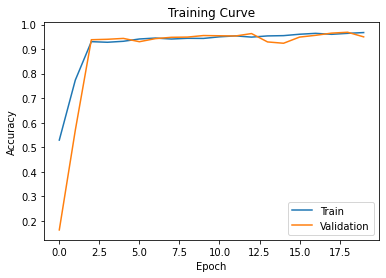

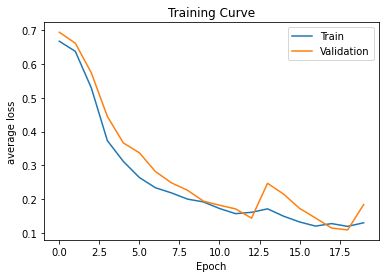

In [ ]:
train_rnn_network(model1, train_iter, valid_iter, num_epochs=20, learning_rate=1e-4 )

### Part (c)

Choose at least 4 hyperparameters to tune. Explain how you tuned the hyperparameters.
You don't need to include your training curve for every model you trained.
Instead, explain what hyperparemters you tuned, what the best validation accuracy was,
and the reasoning behind the hyperparameter decisions you made.




$\color{blue}{\text{ }}$  

- <font color=blue>Hyperparameter-1: learning rate
<font color=black>

<font color=blue>Decreasing learning rate decrease accuracy and increasing learning rate will not change the accuracy significantly.
<font color=black>

In [ ]:
model2=RNN_char(len(text_field.vocab.stoi),50,2, 1)


Epoch 1; Loss 0.037972; Train Acc 0.962469; Val Acc 0.969507; average Train loss 0.102394; average Val loss 0.098612
Epoch 2; Loss 0.158984; Train Acc 0.972143; Val Acc 0.969507; average Train loss 0.072247; average Val loss 0.082879
Epoch 3; Loss 0.029335; Train Acc 0.945788; Val Acc 0.905830; average Train loss 0.170275; average Val loss 0.304899
Epoch 4; Loss 0.044907; Train Acc 0.956631; Val Acc 0.946188; average Train loss 0.141349; average Val loss 0.198487
Epoch 5; Loss 0.093002; Train Acc 0.902419; Val Acc 0.830493; average Train loss 0.270946; average Val loss 0.461214
Epoch 6; Loss 0.187938; Train Acc 0.946956; Val Acc 0.951570; average Train loss 0.126206; average Val loss 0.121198
Epoch 7; Loss 0.018802; Train Acc 0.944287; Val Acc 0.938117; average Train loss 0.150337; average Val loss 0.183143
Epoch 8; Loss 0.269608; Train Acc 0.950125; Val Acc 0.956054; average Train loss 0.145166; average Val loss 0.141293
Epoch 9; Loss 0.017552; Train Acc 0.955796; Val Acc 0.951570; av

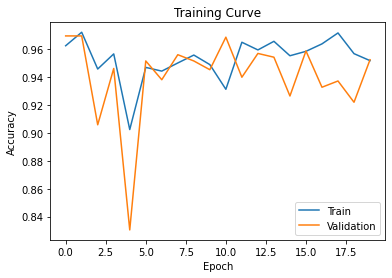

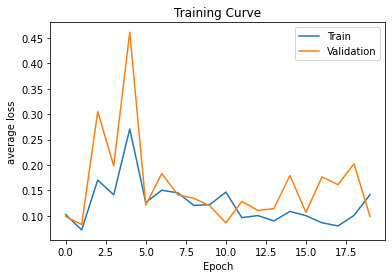

In [ ]:
train_rnn_network(model2, train_iter, valid_iter, num_epochs=20, learning_rate=1e-2)

Epoch 1; Loss 0.654214; Train Acc 0.472856; Val Acc 0.869955; average Train loss 0.690446; average Val loss 0.647134
Epoch 2; Loss 0.720131; Train Acc 0.472856; Val Acc 0.869955; average Train loss 0.690202; average Val loss 0.647518
Epoch 3; Loss 0.659209; Train Acc 0.472856; Val Acc 0.869058; average Train loss 0.690007; average Val loss 0.647883
Epoch 4; Loss 0.682610; Train Acc 0.474004; Val Acc 0.869058; average Train loss 0.689756; average Val loss 0.648356
Epoch 5; Loss 0.673818; Train Acc 0.474004; Val Acc 0.869058; average Train loss 0.689549; average Val loss 0.648738
Epoch 6; Loss 0.718935; Train Acc 0.474004; Val Acc 0.869058; average Train loss 0.689349; average Val loss 0.649151
Epoch 7; Loss 0.718056; Train Acc 0.474004; Val Acc 0.869058; average Train loss 0.689138; average Val loss 0.649542
Epoch 8; Loss 0.717801; Train Acc 0.475152; Val Acc 0.869058; average Train loss 0.688904; average Val loss 0.649969
Epoch 9; Loss 0.658265; Train Acc 0.476300; Val Acc 0.869058; av

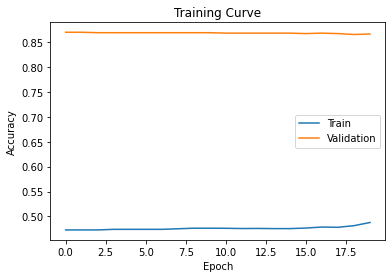

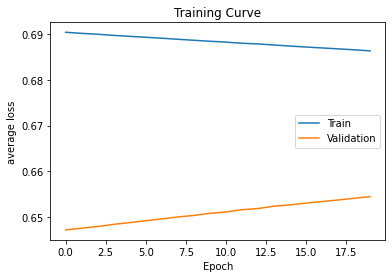

In [ ]:
model3=RNN_char(len(text_field.vocab.stoi),50,2, 1)
train_rnn_network(model3, train_iter, valid_iter, num_epochs=20, learning_rate=1e-6)


$\color{blue}{\text{Hyperparameter-2: }}$  

- <font color=blue>Number of epoch <font color=black>

-<font color=blue> Decreasing Number of epoch will decrease accuracy and increasing number of epoch more than 20 will not change accuracy of the model <font color=black>

Epoch 1; Loss 0.671603; Train Acc 0.608168; Val Acc 0.290583; average Train loss 0.662705; average Val loss 0.678506
Epoch 2; Loss 0.589298; Train Acc 0.826800; Val Acc 0.693274; average Train loss 0.623285; average Val loss 0.652428
Epoch 3; Loss 0.303788; Train Acc 0.914876; Val Acc 0.936323; average Train loss 0.436610; average Val loss 0.498512
Epoch 4; Loss 0.180062; Train Acc 0.933082; Val Acc 0.956054; average Train loss 0.346853; average Val loss 0.389311
Epoch 5; Loss 0.398142; Train Acc 0.937018; Val Acc 0.963229; average Train loss 0.285011; average Val loss 0.303217


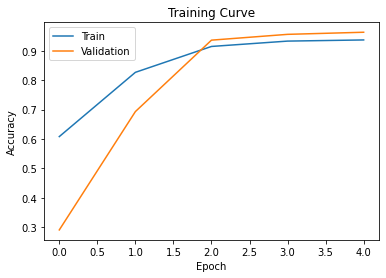

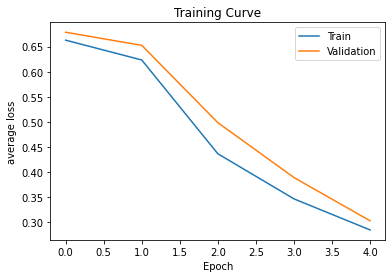

In [ ]:
model4=RNN_char(len(text_field.vocab.stoi),50,2, 1)
train_rnn_network(model4, train_iter, valid_iter, num_epochs=5, learning_rate=1e-4)



$\color{blue}{\text{Hyperparameter-3: }}$  

- <font color=blue>Two ways that we pool the RNN outputs is one of the "hyperparameters" that you can choose to tune later on.  
method 1 <font color=black>
```
out, _ = self.rnn(x)
self.fc(torch.max(out, dim=1)[0])
```
<font color=blue>
method 2 <font color=black>

```
out, _ = self.rnn(x)
out = torch.cat([torch.max(out, dim=1)[0],
                 torch.mean(out, dim=1)], dim=1)
self.fc(out)
```
<font color=black>



- <font color=blue>In this part the second method has been used to see the imapct of that method on the output. This method has not improved the model.<font color=black>

In [ ]:
model5=RNN_char(len(text_field.vocab.stoi),50,2, method=2)

Epoch 1; Loss 3.858198; Train Acc 0.526980; Val Acc 0.130045; average Train loss 4.058332; average Val loss 4.256369
Epoch 2; Loss 3.632403; Train Acc 0.526980; Val Acc 0.130045; average Train loss 3.784366; average Val loss 3.905711
Epoch 3; Loss 3.459482; Train Acc 0.526980; Val Acc 0.130045; average Train loss 3.536224; average Val loss 3.545825
Epoch 4; Loss 3.409982; Train Acc 0.526980; Val Acc 0.130045; average Train loss 3.417725; average Val loss 3.384442
Epoch 5; Loss 3.421462; Train Acc 0.526980; Val Acc 0.130045; average Train loss 3.355311; average Val loss 3.309990
Epoch 6; Loss 3.301832; Train Acc 0.526980; Val Acc 0.130045; average Train loss 3.314861; average Val loss 3.265206
Epoch 7; Loss 3.288054; Train Acc 0.526980; Val Acc 0.130045; average Train loss 3.284508; average Val loss 3.232310
Epoch 8; Loss 3.257203; Train Acc 0.526980; Val Acc 0.130045; average Train loss 3.260738; average Val loss 3.206188
Epoch 9; Loss 3.280692; Train Acc 0.526980; Val Acc 0.130045; av

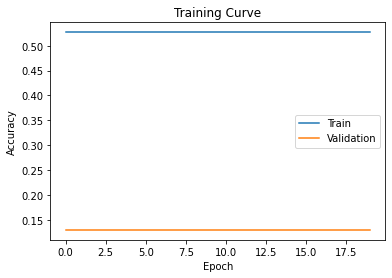

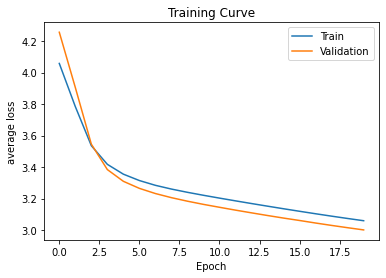

In [ ]:
train_rnn_network(model5, train_iter, valid_iter, num_epochs=20, learning_rate=1e-4)


$\color{blue}{\text{Hyperparameter-4: }}$  

- <font color=blue> I use  a multi-layer long short-term memory (LSTM) RNN in this section. The accuracy of model over train set decreased and it increased over validation set. So, we would choose base model as the best model for next part.
 <font color=black>

In [ ]:
class RNN_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, method=1):
        super(RNN_LSTM, self).__init__()
        self.ohe = one_hot_encoding
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        if method==1:
          self.fc = nn.Linear(hidden_size, num_classes)
        else:
          self.fc = nn.Linear(hidden_size*2, num_classes)
        self.method=method

    def forward(self, x):
        method=self.method
        x = self.ohe(x)
        h0 = torch.zeros(1, x.size(0), self.hidden_size)
        c0 = torch.zeros(1, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0,c0))
        if method==1:
          out = self.fc(torch.max(out, dim=1)[0])
        else:
          out = torch.cat([torch.max(out, dim=1)[0], torch.mean(out, dim=1)], dim=1)
          self.fc(out)
        return out

In [ ]:
model6=RNN_LSTM(len(text_field.vocab.stoi),50,2, 1)

Epoch 1; Loss 0.637038; Train Acc 0.526980; Val Acc 0.130045; average Train loss 0.682426; average Val loss 0.705458
Epoch 2; Loss 0.749732; Train Acc 0.526980; Val Acc 0.130045; average Train loss 0.672151; average Val loss 0.710185
Epoch 3; Loss 0.454223; Train Acc 0.526980; Val Acc 0.130045; average Train loss 0.577563; average Val loss 0.708988
Epoch 4; Loss 0.376159; Train Acc 0.940463; Val Acc 0.950673; average Train loss 0.419527; average Val loss 0.606203
Epoch 5; Loss 0.553829; Train Acc 0.936198; Val Acc 0.961435; average Train loss 0.388171; average Val loss 0.574940
Epoch 6; Loss 0.253197; Train Acc 0.938002; Val Acc 0.962332; average Train loss 0.364459; average Val loss 0.535688
Epoch 7; Loss 0.630426; Train Acc 0.938658; Val Acc 0.965919; average Train loss 0.339045; average Val loss 0.479879
Epoch 8; Loss 0.486119; Train Acc 0.948007; Val Acc 0.956951; average Train loss 0.322327; average Val loss 0.466255
Epoch 9; Loss 0.256656; Train Acc 0.901263; Val Acc 0.973094; av

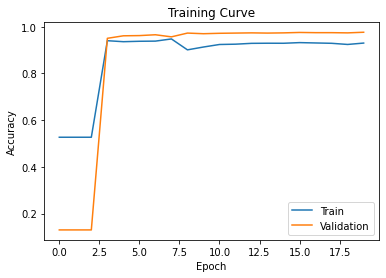

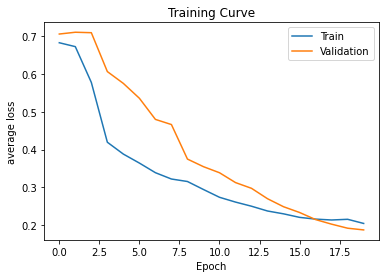

In [ ]:
train_rnn_network(model6, train_iter, valid_iter, num_epochs=20, learning_rate=1e-4)


$\color{blue}{\text{Hyperparameter-5: Increasing Hidden Size }}$  

- <font color=blue> I want to see the impact of increasing hidden size on the result. This is the best model based on accuracy.
 <font color=black>

In [ ]:
model7=RNN_char(len(text_field.vocab.stoi),100,2, 1)

Epoch 1; Loss 0.717040; Train Acc 0.515495; Val Acc 0.151570; average Train loss 0.666183; average Val loss 0.687672
Epoch 2; Loss 0.605159; Train Acc 0.876376; Val Acc 0.764126; average Train loss 0.622102; average Val loss 0.650914
Epoch 3; Loss 0.248460; Train Acc 0.912786; Val Acc 0.922870; average Train loss 0.398473; average Val loss 0.466147
Epoch 4; Loss 0.318193; Train Acc 0.946317; Val Acc 0.951570; average Train loss 0.273017; average Val loss 0.300621
Epoch 5; Loss 0.117862; Train Acc 0.934462; Val Acc 0.964126; average Train loss 0.243970; average Val loss 0.225579
Epoch 6; Loss 0.198353; Train Acc 0.953260; Val Acc 0.960538; average Train loss 0.198157; average Val loss 0.233920
Epoch 7; Loss 0.078089; Train Acc 0.949365; Val Acc 0.966816; average Train loss 0.173024; average Val loss 0.163031
Epoch 8; Loss 0.078913; Train Acc 0.941575; Val Acc 0.972197; average Train loss 0.195232; average Val loss 0.131937
Epoch 9; Loss 0.252407; Train Acc 0.927858; Val Acc 0.974888; av

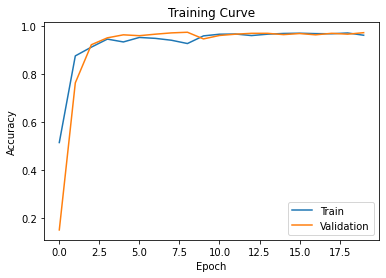

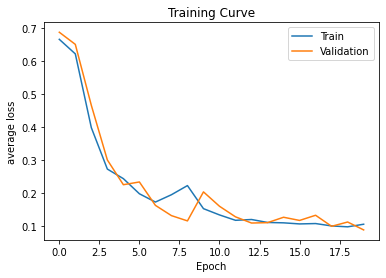

In [ ]:
train_rnn_network(model7, train_iter, valid_iter, num_epochs=20, learning_rate=1e-4)

### Part (d)

Before we deploy a machine learning model, we usually want to have a better understanding
of how our model performs beyond its validation accuracy. An important metric to track is
*how well our model performs in certain subsets of the data*.

In particular, what is the model's error rate amongst data with negative labels?
This is called the **false positive rate**.

What about the model's error rate amongst data with positive labels?
This is called the **false negative rate**.

Report your final model's false positive and false negative rate across the
validation set.

In [ ]:
# Create a Dataset of only spam validation examples
valid_spam = torchtext.legacy.data.Dataset(
    [e for e in valid.examples if e.label == 1],
    valid.fields)
# Create a Dataset of only non-spam validation examples
valid_nospam = torchtext.legacy.data.Dataset(
    [e for e in valid.examples if e.label == 0],
    valid.fields) # TODO

In [ ]:
valid_spam_iter=torchtext.legacy.data.BucketIterator(valid_spam,
                                           batch_size=32,
                                           sort_key=lambda x: len(x.sms), # to minimize padding
                                           sort_within_batch=True,        # sort within each batch
                                           repeat=False)


In [ ]:
criterion = nn.CrossEntropyLoss()
false_positive_rate=get_accuracy(model7, valid_spam_iter, criterion)[0]
print("The false positive rate of the best model is:", 1-false_positive_rate)

The false positive rate of the best model is: 0.10416666666666663


In [ ]:
valid_nospam_iter=torchtext.legacy.data.BucketIterator(valid_nospam,
                                           batch_size=32,
                                           sort_key=lambda x: len(x.sms), # to minimize padding
                                           sort_within_batch=True,        # sort within each batch
                                           repeat=False)


In [ ]:
false_negative_rate=get_accuracy(model7, valid_nospam_iter, criterion)[0]
print("The false positive rate of the best model is:", 1-false_negative_rate)

The false positive rate of the best model is: 0.015447991761071034


### Part (e)

The impact of a false positive vs a false negative can be drastically different.
If our spam detection algorithm was deployed on your phone, what is the impact
of a false positive on the phone's user? What is the impact of a false negative?





$\color{blue}{\text{ }}$  

- <font color=blue> The effect of a **false positive** is more dangerous because it would consider an sms that is not spam to be spam. It could be inefficient because if we had an important sms that was sent to spam when it was actually not spam, we may never know about that important message or we may retrieve and read that message so late.<font color=black>

- <font color=blue> On the other hand, the effect of a **false negative** is not alarming, and this is where it would allow a spam sms to pass through. So having a false negative rate of 0.0317 could be considered good, beacuse people can read the spams that has been labeled as non spam one and delete them without any consequence. <font color=black>


## Part 4. Evaluation

### Part (a)

Report the final test accuracy of your model.

In [ ]:
test_iter = torchtext.legacy.data.BucketIterator(test,
                                           batch_size=32,
                                           sort_key=lambda x: len(x.sms),
                                           sort_within_batch=True,
                                           repeat=False)

In [ ]:
criterion = nn.CrossEntropyLoss()
test_acc=get_accuracy(model7, test_iter, criterion)[0]
print("The accuracy of the best model for test set is:", test_acc)

The accuracy of the best model for test set is: 0.9712746858168761


### Part (b)

Report the false positive rate and false negative rate of your model across the test set.

In [ ]:
# Create a Dataset of only spam validation examples
test_spam = torchtext.legacy.data.Dataset(
    [e for e in test.examples if e.label == 1],
    valid.fields)
# Create a Dataset of only non-spam validation examples
test_nospam = torchtext.legacy.data.Dataset(
    [e for e in test.examples if e.label == 0],
    valid.fields) # TODO

In [ ]:
test_spam_iter=torchtext.legacy.data.BucketIterator(test_spam,
                                           batch_size=32,
                                           sort_key=lambda x: len(x.sms), # to minimize padding
                                           sort_within_batch=True,        # sort within each batch
                                           repeat=False)


In [ ]:
criterion = nn.CrossEntropyLoss()
false_positive_rate=get_accuracy(model7, test_spam_iter, criterion)[0]
print("The false positive rate of the best model is:", 1-false_positive_rate)

The false positive rate of the best model is: 0.09659090909090906


In [ ]:
test_nospam_iter=torchtext.legacy.data.BucketIterator(test_nospam,
                                           batch_size=32,
                                           sort_key=lambda x: len(x.sms), # to minimize padding
                                           sort_within_batch=True,        # sort within each batch
                                           repeat=False)


In [ ]:
false_negative_rate=get_accuracy(model7, test_nospam_iter, criterion)[0]
print("The false positive rate of the best model is:", 1-false_negative_rate)

The false positive rate of the best model is: 0.015991471215351827


### Part (c)

What is your model's prediction of the **probability** that
the SMS message "machine learning is sooo cool!" is spam?

Hint: To begin, use `text_field.vocab.stoi` to look up the index
of each character in the vocabulary.

In [ ]:
msg = "machine learning is sooo cool!"
msg_new=list(tuple(msg))
msg_new2=[]
for i in enumerate(msg_new):
  msg_new2.append(text_field.vocab.stoi[i[1]])

msg_new2=torch.tensor(msg_new2).unsqueeze(0)
prob=model7(msg_new2)

prob

tensor([[ 1.6808, -1.5270]], grad_fn=<AddmmBackward0>)

In [ ]:
import math

def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [ ]:
print("The model's prediction of the probability that the message is spam is:", sigmoid(-(prob[0][1].item())))

The model's prediction of the probability that the message is spam is: 0.8215653043444728


### Part (d)

Do you think detecting spam is an easy or difficult task?

Since machine learning models are expensive to train and deploy, it is very
important to compare our models against baseline models: a simple
model that is easy to build and inexpensive to run that we can compare our
recurrent neural network model against.

Explain how you might build a simple baseline model. This baseline model
can be a simple neural network (with very few weights), a hand-written algorithm,
or any other strategy that is easy to build and test.

**Do not actually build a baseline model. Instead, provide instructions on
how to build it.**





$\color{blue}{\text{ }}$  

- <font color=blue> Detecting Spam is a difficult task because companies and scammers always try to write their messages in a way to not be classified as spam and hackers try to find new ways to send messages that can be labeled as no spam.<font color=black>

- <font color=blue> There are different ways for detecting spam emails. Some of these ways like support vector machines (SVM), Content Based Filtering Technique, and etc has been mentioned in articles.<font color=black>

- <font color=blue> One of the methods that has been used widely is solving the problem using a classifier method like SVM.<font color=black>

- <font color=blue> I think using SVM would solve this problem properly.<font color=black>

<font color=blue>
The way we would build the simple baseline model using SVM is the following:

1. Load the dataset containing the spam/ham emails (make sure the labels and emails are in separate dataframes).

2. Split data into training, validation and testing.

3. Convert the text to integers using CountVectorizer() from sklearn (similar to count number of differet words in every email).

4. Perform support vector classification using SVC from sklearn, which is  classification method for classifing spam/non-spam.

This method has been used in the following link:
https://www.youtube.com/watch?v=exHwwy9kVcg

In the link they achieved 98 accuracy.


# PART B - Transfer Learning

In this part we will compare our earlier model with one that takes advantage of a generative RNN model to improve the prediction. There are several ways to implement transfer learning with RNNs, here we will use an approach known as ULMFiT developed by fastai. Rather than rebuilding the model from scratch, we will take advantage of the fastai library.

Provided below is some helper code to get you started.

#### Helper Code

In [ ]:
# install relevant libraries
!pip install fastai

In [ ]:
# load relevant libraries
from fastai import *
import pandas as pd
import numpy as np
from functools import partial
import io
import os
from fastai.text import *

In [ ]:
# download SPAM data
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
!unzip smsspamcollection.zip

--2022-03-23 21:30:31--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 203415 (199K) [application/x-httpd-php]
Saving to: ‘smsspamcollection.zip.1’

smsspamcollection.z 100%[===================>] 198.65K   337KB/s    in 0.6s    

2022-03-23 21:30:32 (337 KB/s) - ‘smsspamcollection.zip.1’ saved [203415/203415]

Archive:  smsspamcollection.zip
replace SMSSpamCollection? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: SMSSpamCollection       
replace readme? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: readme                  


This time we will load the data using pandas.

In [ ]:
# set up data and verify
df1 = pd.read_csv('SMSSpamCollection', sep='\t',  header=None, names=['target', 'text'])
df1.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# check distribution
df1['target'].value_counts()

ham     4825
spam     747
Name: target, dtype: int64

Split the data into training and validation datasets.

In [ ]:
# split the data and check dimensions

from sklearn.model_selection import train_test_split

# split data into training and validation set
df_trn, df_val = train_test_split(df1, stratify = df1['target'], test_size = 0.3, random_state = 999)

In [ ]:
df_trn.shape, df_val.shape

((3900, 2), (1672, 2))

### Create the language model
Esentially, the language model contains the structure of the language (English in this case), allowing us to quickly use in a classification model, skipping the part of learning the semantics of the language from scratch.

Creating a language model from scratch can be intensive due to the sheer size of data. Instead we will download the pre-trained model, which is a neural network (NN) with an AWD_LSTM architecture. By setting pretrained = True we say to fastai to download the weights from the trained model (a corpus of 103 MM of wikipedia articles).

In [ ]:
# create pretrained language model data
data_lm = TextLMDataBunch.from_df(train_df = df_trn, valid_df = df_val, path = "")
lang_mod = language_model_learner(data_lm,  arch = AWD_LSTM, pretrained = True, drop_mult=1.)

/usr/local/lib/python3.7/dist-packages/fastai/core.py:302: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array(a, dtype=dtype, **kwargs)


### Testing the language model


In [ ]:
for i in range(5):
  print(lang_mod.predict("The problem usually starts when", n_words=10))

The problem usually starts when the week is off . The regular daily medical
The problem usually starts when a weather sub - station becomes freezing , or even
The problem usually starts when there is little time for river , and only players
The problem usually starts when the player is on the joke or given the chance
The problem usually starts when people find and watch live . For more than


Each time we excecute the `predict`, we get a different random sentence, completed with the number of choosen words (`n_words`).

Try your own sentences!

### Fine-tuning the language model
The language model that we have "loaded" is great for generating wikipedia-like sentances, but here we're more interested in generating data like our email dataset.

Make sure to enable GPU for this step or it make takes several hours to train.

In [ ]:
# fine-tune language model data
lang_mod.fit_one_cycle(4, max_lr= 5e-02)
lang_mod.freeze_to(-1)
lang_mod.fit_one_cycle(3, slice(1e-2/(2.6**4), 1e-2))
lang_mod.freeze_to(-2)
lang_mod.fit_one_cycle(3, slice(3e-3/(2.6**4), 1e-3))
lang_mod.unfreeze()
lang_mod.fit_one_cycle(3, slice(3e-3/(2.6**4), 1e-3))

# save language model
lang_mod.save_encoder('my_awsome_encoder')

epoch,train_loss,valid_loss,accuracy,time
0,5.559665,3.838634,0.271429,00:06
1,4.837364,3.884766,0.257143,00:06
2,4.381217,3.907408,0.314286,00:06
3,4.058231,3.894445,0.285714,00:06


epoch,train_loss,valid_loss,accuracy,time
0,3.586014,3.901195,0.271429,00:06
1,3.545844,3.909892,0.285714,00:06
2,3.479261,3.902932,0.300000,00:06


epoch,train_loss,valid_loss,accuracy,time
0,3.397920,3.910488,0.271429,00:06
1,3.368337,3.908440,0.271429,00:06
2,3.357924,3.906763,0.271429,00:06


epoch,train_loss,valid_loss,accuracy,time
0,3.328964,3.899337,0.271429,00:08
1,3.295834,3.914949,0.257143,00:08
2,3.261016,3.892393,0.257143,00:08


### Classification model
Now we can train a classification model that will identify spam and non-spam messages. Since we used a fastai language model, it will be easier to just continue working with the fastai library.

In [ ]:
# Classifier model data
data_clas = TextClasDataBunch.from_df(path = "", train_df = df_trn,  valid_df = df_val, vocab=data_lm.train_ds.vocab, bs=32)

/usr/local/lib/python3.7/dist-packages/fastai/core.py:302: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array(a, dtype=dtype, **kwargs)


/usr/local/lib/python3.7/dist-packages/fastai/text/data.py:124: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sort_idx = np.concatenate(np.random.permutation(ck_idx[1:])) if len(ck_idx) > 1 else np.array([],dtype=np.int)
<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


In [ ]:
data_clas.show_batch()

/usr/local/lib/python3.7/dist-packages/fastai/text/data.py:124: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sort_idx = np.concatenate(np.random.permutation(ck_idx[1:])) if len(ck_idx) > 1 else np.array([],dtype=np.int)
<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


text,target
"xxbos xxmaj the last thing i ever wanted to do was hurt you . xxmaj and i did n't think it would have . xxmaj you 'd laugh , be embarassed , delete the xxunk and keep going . xxmaj but as far as i knew , it was n't even up . xxmaj the fact that you even felt like i would do it to hurt you shows you",ham
"xxbos xxmaj sad story of a xxmaj man - xxmaj last week was my b'day . xxmaj my xxmaj wife did'nt wish me . xxmaj my xxmaj parents forgot n so did my xxmaj kids . i went to work . xxmaj even my xxmaj colleagues did not wish . xxmaj as i entered my cabin my xxup pa said , '' xxmaj happy xxmaj b'day xxmaj boss ! !",ham
"xxbos xxmaj solve d xxmaj case : a xxmaj man xxmaj was xxmaj found xxmaj murdered xxmaj on < xxup decimal > . < # > afternoon . 1,his wife called xxmaj police . 2,police questioned everyone . 3,wife : xxmaj sir , i was sleeping , when the murder took place . 4.cook : i was cooking . 5.gardener : i was picking vegetables . 6.house - xxmaj maid",ham
"xxbos xxmaj hey sweet , i was wondering when you had a moment if you might come to me ? i want to send a file to someone but it wo n't go over yahoo for them because their connection sucks , remember when you set up that page for me to go to and download the xxunk xxunk ? xxmaj could you tell me how to do that ?",ham
"xxbos xxmaj no i 'm not . i ca n't give you everything you want and need . xxmaj you actually could do better for yourself on yor own -- you've got more money than i do . i ca n't get work , i ca n't get a man , i ca n't pay the rent , i ca n't even fill my fucking gas tank . yes ,",ham


In [ ]:
# create the classifier
learn_classifier = text_classifier_learner(data_clas, drop_mult=0.7, arch = AWD_LSTM)

In [ ]:
# load language model
learn_classifier.load_encoder('my_awsome_encoder')

RNNLearner(data=TextClasDataBunch;

Train: LabelList (3900 items)
x: TextList
xxbos i liked your new house,xxbos xxmaj xxunk i 'm walking in xxunk now ü faster come down ... xxmaj me very hungry ...,xxbos xxmaj wan2 win a meet+greet with xxmaj westlife 4 u or a m8 ? xxmaj they are currently on what tour ? 1)unbreakable , 2)untamed , 3)unkempt . xxmaj text 1,2 or 3 to 83049 . xxmaj cost 50p + std text,xxbos xxmaj otherwise had part time job na - tuition ..,xxbos xxmaj wait , do you know if xxunk in town ? i bet she does hella drugs !
y: CategoryList
ham,ham,spam,ham,ham
Path: .;

Valid: LabelList (1672 items)
x: TextList
xxbos xxmaj not a lot has happened here . xxmaj feels very xxunk . xxmaj xxunk is at her xxunk and xxunk is working lots . xxmaj just me and xxunk in at the mo . xxmaj how have you been ?,xxbos xxmaj the current xxunk bid is xxunk . xxmaj to xxunk this auction send xxup out . xxmaj customer xxmaj care : xxunk,xxbos xxmaj are you free xxunk i call now ?,xxbos xxmaj cold 

epoch,train_loss,valid_loss,accuracy,time


/usr/local/lib/python3.7/dist-packages/fastai/text/data.py:124: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sort_idx = np.concatenate(np.random.permutation(ck_idx[1:])) if len(ck_idx) > 1 else np.array([],dtype=np.int)
<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.
Min numerical gradient: 1.45E-01
Min loss divided by 10: 3.63E-02


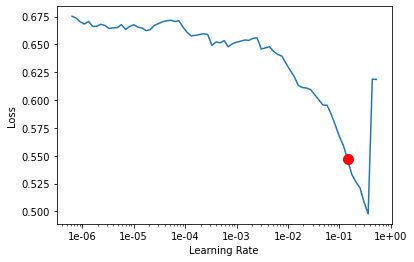

In [ ]:
# train classifier
learn_classifier.lr_find()
learn_classifier.recorder.plot(suggestion=True)

In [ ]:
learn_classifier.fit_one_cycle(5, max_lr=1e-2, moms=(0.8,0.7))

epoch,train_loss,valid_loss,accuracy,time
0,0.390554,0.065109,0.981459,00:09
1,0.192405,0.064630,0.983254,00:09
2,0.118402,0.085098,0.984450,00:08
3,0.106247,0.071088,0.986244,00:09
4,0.079216,0.076424,0.980263,00:09


/usr/local/lib/python3.7/dist-packages/fastai/text/data.py:124: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sort_idx = np.concatenate(np.random.permutation(ck_idx[1:])) if len(ck_idx) > 1 else np.array([],dtype=np.int)
<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
/usr/local/lib/python3.7/dist-packages/fastai/text/data.py:124: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must

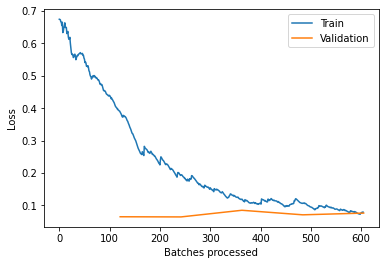

In [ ]:
learn_classifier.recorder.plot_losses()

epoch,train_loss,valid_loss,accuracy,time


/usr/local/lib/python3.7/dist-packages/fastai/text/data.py:124: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sort_idx = np.concatenate(np.random.permutation(ck_idx[1:])) if len(ck_idx) > 1 else np.array([],dtype=np.int)
<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.
Min numerical gradient: 6.31E-07
Min loss divided by 10: 3.63E-06


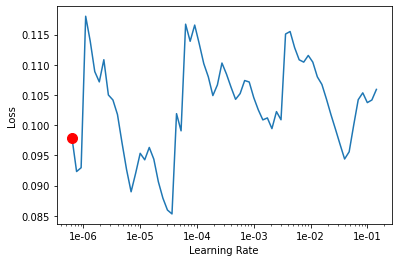

In [ ]:
lang_mod.freeze_to(-1)

learn_classifier.lr_find()
learn_classifier.recorder.plot(suggestion=True)

Test out the classification model on spam and non-spam examples.

In [ ]:
# predict
learn_classifier.predict('did you buy the groceries for dinner? :)')

(Category tensor(0), tensor(0), tensor([9.9999e-01, 1.1263e-05]))

In [ ]:
# predict
learn_classifier.predict('Free entry call back now')

(Category tensor(1), tensor(1), tensor([0.4553, 0.5447]))

Next we will evaluate on all of our validation data.

In [ ]:
# get predictions from validation
valid_preds, valid_label=learn_classifier.get_preds(ds_type=DatasetType.Valid, ordered=True)
valid_preds.shape

torch.Size([1672, 2])

## Part 1. Evaluate Performance

### Part (a)

Implement the above helper code for spam detection.

What is the accuracy obtained with ULMFiT? How does ULMFiT compare to the approach in the first part using only LSTM?



$\color{blue}{\text{ }}$  

- <font color=blue> The accuracy obtained with ULMFiT is 0.9802 that is higher than the accuracy from previous part .<font color=black>



### Part (b)
Provide a confusion matrix of the performance for the two models. How do they compare? Are there any qualitative differences between the performances (i.e. examine the samples for which the models differred)?




$\color{blue}{\text{ }}$  

- <font color=blue> The Model from part-B (using transfer learning) is  doing better than the model from part-A with RNN , we can see qualitatively that the accuracy is higher. The qualitative difference is that the model from Part_B is performing better for detecting the no-spam messages while the model from part_A  is performing better in detecting the spam messages. The false positive rate of part-B is performing way better. The false negative rate, only part_A model is performing better.<font color=black>

- <font color=blue> AS we discussed **False positive** is more dangerous. So, The model from Part_B with transfer learning is far better.<font color=black>

In [ ]:
from sklearn.metrics import confusion_matrix
pred_label=torch.max(valid_preds,1)[1]

cm1=confusion_matrix(list(valid_label),list(pred_label))
cm1

array([[1448,    0],
       [  33,  191]])

In [ ]:
import torchtext

valid_iter3= torchtext.legacy.data.BucketIterator(df_val,
                                           batch_size=32,
                                           sort_key=lambda x: len(x.sms),
                                           sort_within_batch=True,
                                           repeat=False)

In [ ]:
i=0
for batch in valid_iter:
  y=batch.sms[0]
  label=batch.label
  output = model7(y)
  pred = output.max(1, keepdim=True)[1]

  if i==0:
    valid_label_LSTM=batch.label
    valid_pred_LSTM=pred.reshape(1,-1)[0]
  else:
    valid_label_LSTM=torch.cat((valid_label_LSTM,batch.label),0)
    valid_pred_LSTM=torch.cat((valid_pred_LSTM,pred.reshape(1,-1)[0]),0)
  i+=1


In [ ]:
cm2=confusion_matrix(list(valid_label_LSTM),list(valid_pred_LSTM))
cm2

array([[956,  15],
       [ 15, 129]])

## Part 2. Evaluate on New Data

### Part (a)
What is your model's prediction of the probability that the SMS message "machine learning is sooo cool!" is spam?

In [ ]:
pred_msgml=learn_classifier.predict('machine learning is sooo cool!')
pred_msgml

(Category tensor(0), tensor(0), tensor([1.0000e+00, 3.9536e-14]))

In [ ]:
print("Probability for the message  to be spam is:", pred_msgml[2][1].item())

Probability for the message  to be spam is: 3.953623181878613e-14


### Part (b)
Load 5 sample sentences from your spam mail and test it out out the two models you created. How well do they perform?

In [ ]:
msgs_spam_email=['You have won a £2,000 price! To claim, call 09050000301.',
                 'You have won a guaranteed 32000 award or maybe even £1000 cash to claim ur award call',
                 'You are awarded a SiPix Digital Camera! call 09061221061 from landline. Delivery within 28days.!',
                 'ITS YOUR CHANCE to win 100$ in bitcoin',
                 'Show ur colours! Euro 2004 2-4-1 Offer! Get an England Flag & 3Lions tone on ur phone! ']


<font color=blue> **Part B model: using transfer learning:** <font color=black>


In [ ]:
spam_num=0
for i in msgs_spam_email:
  pred=learn_classifier.predict(i)
  if pred[1]==1:
    spam_num+=1
spam_num=spam_num/5
print("The accuracy of detecting spam emails is:", spam_num)

The accuracy of detecting spam emails is: 1.0



 <font color=blue> **Part A model: using RNN:** <font color=black>

In [ ]:
spam_num_model=0
for j in msgs_spam_email:
  j_new=list(tuple(i))
  j_new2=[]
  for i in enumerate(j_new):
    j_new2.append(text_field.vocab.stoi[i[1]])

  j_new2=torch.tensor(j_new2).unsqueeze(0)
  prob=model7(j_new2)
  pred=prob.max(1,keepdim=True)[1]
  if pred.item()==1:
    spam_num_model+=1
spam_num_model=spam_num_model/5
print("The accuracy of detecting spam emails is:", spam_num_model)

The accuracy of detecting spam emails is: 0.2


<font color=blue> As we can see the accuracy of the model in part B (using transfer learning) is better than the RNN model from part A in detecting spam emails. <font color=blue>

### Part (c)
Load 5 sample sentences from your regular mail and test it out out the two models you created. How well do they perform?

In [ ]:
msgs_nospam_partB=['Job Opportunities in First Year Office-Summer 2022. The First Year Office has at least 2  job opportunities that are available to all returning graduate students.  Details for each position can be found below.',
                   'Dear Students, If you have not yet taken JDE1000H as part of your research program, please sign up for the spring offering by registering via Microsoft form (see below).',
                   'I will run an introduction session on the Final Project tomorrow, Saturday, March 19 from 7-8 PM.',
                   'Thank you so much for the reply and detailed explanation.',
                   'Hi all, Our undergraduate students are organizing their formal dinner dance, details below.  This will be the first dinner dance in two years']


<font color=blue> **Part B model: using transfer learning:** <font color=black>


In [ ]:
nospam_num=0
for i in msgs_nospam_partB:
  pred=learn_classifier.predict(i)
  if pred[1]==0:
    nospam_num+=1
nospam_num=nospam_num/5
print("The accuracy of predicting non-spam is:",nospam_num)

The accuracy of predicting non-spam is: 1.0



 <font color=blue> **Part A model: using RNN:** <font color=black>

In [ ]:
nospam_num2=0
for j in msgs_nospam_partB:
  j_new=list(tuple(i))
  j_new2=[]
  for i in enumerate(j_new):
    j_new2.append(text_field.vocab.stoi[i[1]])

  j_new2=torch.tensor(j_new2).unsqueeze(0)
  prob=model7(j_new2)
  pred=prob.max(1,keepdim=True)[1]
  if pred.item()==0:
    nospam_num2+=1
nospam_num2=nospam_num2/5
print("The accuracy of detecting non-spam emails is:", nospam_num2)

The accuracy of detecting non-spam emails is: 1.0


<font color=blue> As we can see the accuracy of the model in part B (using transfer learning) and  the RNN model from part A  works good in detecting no-spam emails. <font color=blue>

# Results

## Summary

Two spam detection approaches were implemented and compared.

### Model 1

- Character-level LSTM
- Built entirely from scratch
- Learns sequential text representations directly from SMS messages

### Model 2

- Transfer Learning (ULMFiT)
- Fine-tuned pretrained language model
- Uses learned language representations for spam classification

### Key Findings

- Both models successfully distinguish spam from legitimate SMS messages.
- Transfer learning improved classification performance by leveraging pretrained language representations.
- Confusion matrices and probability predictions provide additional insight beyond overall accuracy.

# Conclusion

This notebook demonstrated two modern approaches to spam detection using deep learning. A character-level LSTM established a strong baseline for sequential text classification, while transfer learning with ULMFiT further improved predictive performance by leveraging pretrained language representations. Together, these experiments illustrate the effectiveness of recurrent neural networks and transfer learning for practical NLP classification tasks.